<a href="https://colab.research.google.com/github/venezianof/booksum/blob/main/9Routermioipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 9Router: Token Saver and Model Orchestrator
This notebook will explore the concepts described in the 9Router architecture.

In [ ]:
# Define the tiers as described
tiers = {
    "Tier 1": "Subscription (Claude Code, Codex, GitHub Copilot)",
    "Tier 2": "Cheap (GLM, MiniMax)",
    "Tier 3": "Free (Kiro, Vertex)"
}

print("9Router Configuration Initialized.")
for tier, models in tiers.items():
    print(f"{tier}: {models}")

9Router Configuration Initialized.
Tier 1: Subscription (Claude Code, Codex, GitHub Copilot)
Tier 2: Cheap (GLM, MiniMax)
Tier 3: Free (Kiro, Vertex)


In [11]:
# Definizione della classe BudgetMonitor per gestire i limiti di spesa
class BudgetMonitor:
    def __init__(self, limits):
        self.limits = limits  # Dizionario con limiti per tier, es: {"Tier 2": 5.0}
        self.spending = {tier: 0.0 for tier in limits} # Inizializza la spesa a 0

    def record_usage(self, tier, amount):
        if tier in self.spending:
            self.spending[tier] += amount
            print(f"[Monitor] Gasto en {tier} actualizado: ${self.spending[tier]:.4f} / ${self.limits[tier]:.2f}")
            self._check_threshold(tier)
        else:
            print(f"[Monitor] Advertencia: Tier '{tier}' no definido en los límites del presupuesto.")

    def is_budget_ok(self, tier):
        # Restituisce True se il budget per il tier non è esaurito, altrimenti False
        return self.spending.get(tier, 0) < self.limits.get(tier, float('inf'))

    def _check_threshold(self, tier):
        current_spending = self.spending[tier]
        limit = self.limits[tier]
        remaining = limit - current_spending
        threshold_percent = 0.10 # 10% del límite para el aviso

        if remaining <= 0:
            print(f"[🚫 CRITICAL] Presupuesto para {tier} AGOTADO.")
        elif remaining <= limit * threshold_percent:
            print(f"[⚠️ ALERT] ¡Atención! El presupuesto para {tier} está por debajo del {threshold_percent*100:.0f}% (Restante: ${remaining:.2f})")


In [3]:
tiers = {
    "Tier 1": "Subscription (Claude Code, Codex, GitHub Copilot)",
    "Tier 2": "Cheap (GLM, MiniMax)",
    "Tier 3": "Free (Kiro, Vertex)"
}

In [5]:
def route_request(tier_config, logger, quota_exhausted=False, budget_limited=False):
    """
    Simulates the 9Router logic with a dynamic tier configuration:
    1. Tier 1 if quota is available.
    2. Tier 2 if Tier 1 is exhausted and budget is available.
    3. Tier 3 if Tier 2 is budget limited.
    """
    chosen_tier_name = ""
    if not quota_exhausted:
        chosen_tier_name = "Tier 1"
    elif not budget_limited:
        chosen_tier_name = "Tier 2"
    else:
        chosen_tier_name = "Tier 3"

    chosen_tier_value = tier_config[chosen_tier_name]

    # Log the decision
    logger.log_route_decision(
        chosen_tier_name=chosen_tier_name,
        chosen_tier_value=chosen_tier_value,
        quota_exhausted=quota_exhausted,
        budget_limited=budget_limited,
        tier_config_used=tier_config
    )

    return f"Using {chosen_tier_value}"

# Scenario: Tier 1 quota is exhausted, but we have budget for Tier 2
print(f"Scenario 1: {route_request(tiers, router_logger, quota_exhausted=True, budget_limited=False)}")

# Scenario: All limits reached, falling back to free
print(f"Scenario 2: {route_request(tiers, router_logger, quota_exhausted=True, budget_limited=True)}")

[Logger] Decisione di routing registrata: 2026-05-11 19:34:23 - Scelto: Cheap (GLM, MiniMax)
Scenario 1: Using Cheap (GLM, MiniMax)
[Logger] Decisione di routing registrata: 2026-05-11 19:34:23 - Scelto: Free (Kiro, Vertex)
Scenario 2: Using Free (Kiro, Vertex)


In [9]:
# Configuración de límites (ejemplo)
limits = {"Tier 2": 5.0, "Tier 1": 50.0} # Tier 3 es gratis ($0)
monitor = BudgetMonitor(limits)

# Simulación de uso
monitor.record_usage("Tier 2", 0.0025)
print(f"¿Hay presupuesto para Tier 2?: {monitor.is_budget_ok('Tier 2')}")

NameError: name 'BudgetMonitor' is not defined

In [ ]:
def route_with_budget(quota_exhausted, monitor):
    if not quota_exhausted:
        return "Tier 1"

    if monitor.is_budget_ok("Tier 2"):
        return "Tier 2"

    return "Tier 3"

# Prueba de la lógica con el monitor
print(f"Ruta elegida: {route_with_budget(quota_exhausted=True, monitor=monitor)}")

Ruta elegida: Tier 2


## Simulación de RTK Token Saver
El RTK (Real-Time Kernel) Token Saver optimiza los mensajes enviados a la API (especialmente `tool_results`) para reducir costos sin perder contexto.

In [ ]:
import random

def simulate_rtk_saver(raw_tokens):
    """
    Simula la reducción de tokens mediante técnicas de optimización RTK.
    Según tu diagrama, el ahorro es de aproximadamente 20-40%.
    """
    reduction_factor = random.uniform(0.20, 0.40)
    optimized_tokens = int(raw_tokens * (1 - reduction_factor))
    savings = raw_tokens - optimized_tokens
    return optimized_tokens, savings, reduction_factor * 100

# Ejemplo de uso con una solicitud de 10,000 tokens
raw_input = 10000
optimized, saved, percent = simulate_rtk_saver(raw_input)

print(f"--- Reporte RTK ---")
print(f"Tokens Originales: {raw_input}")
print(f"Tokens Optimizados: {optimized}")
print(f"Tokens Ahorrados: {saved} ({percent:.2f}%)")

--- Reporte RTK ---
Tokens Originales: 10000
Tokens Optimizados: 6013
Tokens Ahorrados: 3987 (39.87%)


In [ ]:
import pandas as pd

# Costo hipotético por 1M de tokens en Tier 2
COST_PER_1M = 0.60

def simulate_batch_requests(num_requests=10):
    total_raw_tokens = 0
    total_optimized_tokens = 0
    total_cost_saved = 0.0

    results = []

    for i in range(num_requests):
        raw_tokens = random.randint(1000, 15000)
        optimized, saved, p = simulate_rtk_saver(raw_tokens)

        # Calcular costos
        cost_original = (raw_tokens / 1_000_000) * COST_PER_1M
        cost_optimized = (optimized / 1_000_000) * COST_PER_1M

        # Registrar en el monitor
        monitor.record_usage("Tier 2", cost_optimized)

        total_raw_tokens += raw_tokens
        total_optimized_tokens += optimized
        total_cost_saved += (cost_original - cost_optimized)

        results.append({
            "Req": i+1,
            "Original": raw_tokens,
            "Optimized": optimized,
            "Saved": saved,
            "% Savings": f"{p:.1f}%"
        })

    display(pd.DataFrame(results))
    print(f"\n--- Resumen Acumulado ---")
    print(f"Total Tokens Originales: {total_raw_tokens}")
    print(f"Total Tokens Optimizados: {total_optimized_tokens}")
    print(f"Ahorro Total en Tokens: {total_raw_tokens - total_optimized_tokens}")
    print(f"Dinero Ahorrado (Estimado Tier 2): ${total_cost_saved:.6f}")

simulate_batch_requests(10)

[Monitor] Gasto en Tier 2 actualizado: $0.0039 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0094 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0110 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0142 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0153 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0183 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0192 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0220 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0267 / $5.00
[Monitor] Gasto en Tier 2 actualizado: $0.0287 / $5.00


,Req,Original,Optimized,Saved,% Savings
0,1,3486,2295,1191,34.2%
1,2,12478,9256,3222,25.8%
2,3,3651,2597,1054,28.9%
3,4,8181,5418,2763,33.8%
4,5,2545,1789,756,29.7%
5,6,7294,5059,2235,30.6%
6,7,1904,1404,500,26.2%
7,8,6085,4694,1391,22.9%
8,9,10578,7800,2778,26.3%
9,10,4936,3437,1499,30.4%



--- Resumen Acumulado ---
Total Tokens Originales: 61138
Total Tokens Optimizados: 43749
Ahorro Total en Tokens: 17389
Dinero Ahorrado (Estimado Tier 2): $0.010433


### Test dell'Avviso di Soglia (10%)
Questa cella simula un utilizzo intensivo del Tier 2 per innescare l'avviso automatico implementato nella classe `BudgetMonitor`.

In [ ]:
print(f"--- Simulazione Stress Test Budget ---")
# Forziamo un consumo elevato per arrivare vicini al limite di $5.00
# Ogni blocco simula un costo di $0.50
consumo_blocco = 0.50

for i in range(10):
    print(f"\nEsecuzione blocco di richieste #{i+1}")
    monitor.record_usage("Tier 2", consumo_blocco)

    if monitor.spending["Tier 2"] >= monitor.limits["Tier 2"]:
        break

--- Simulazione Stress Test Budget ---

Esecuzione blocco di richieste #1
[Monitor] Gasto en Tier 2 actualizado: $0.5025 / $5.00

Esecuzione blocco di richieste #2
[Monitor] Gasto en Tier 2 actualizado: $1.0025 / $5.00

Esecuzione blocco di richieste #3
[Monitor] Gasto en Tier 2 actualizado: $1.5025 / $5.00

Esecuzione blocco di richieste #4
[Monitor] Gasto en Tier 2 actualizado: $2.0025 / $5.00

Esecuzione blocco di richieste #5
[Monitor] Gasto en Tier 2 actualizado: $2.5025 / $5.00

Esecuzione blocco di richieste #6
[Monitor] Gasto en Tier 2 actualizado: $3.0025 / $5.00

Esecuzione blocco di richieste #7
[Monitor] Gasto en Tier 2 actualizado: $3.5025 / $5.00

Esecuzione blocco di richieste #8
[Monitor] Gasto en Tier 2 actualizado: $4.0025 / $5.00

Esecuzione blocco di richieste #9
[Monitor] Gasto en Tier 2 actualizado: $4.5025 / $5.00
[⚠️ ALERT] ¡Atención! El presupuesto para Tier 2 está por debajo del 10% (Restante: $0.4975)

Esecuzione blocco di richieste #10
[Monitor] Gasto en Tie

## Traduzione dei Formati (OpenAI ↔ Claude)
Per permettere l'orchestrazione fluida tra Tier diversi, 9Router deve tradurre i messaggi nel formato corretto per ogni provider.

In [ ]:
class FormatTranslator:
    @staticmethod
    def openai_to_claude(messages):
        """Converte una lista di messaggi OpenAI in formato Anthropic/Claude."""
        claude_messages = []
        system_prompt = ""

        for msg in messages:
            role = msg["role"]
            content = msg["content"]

            if role == "system":
                system_prompt = content
            elif role == "user":
                claude_messages.append({"role": "user", "content": content})
            elif role == "assistant":
                claude_messages.append({"role": "assistant", "content": content})

        return system_prompt, claude_messages

    @staticmethod
    def claude_to_openai(claude_messages, system_prompt=""):
        """Converte messaggi Claude e system prompt in formato OpenAI."""
        openai_messages = []
        if system_prompt:
            openai_messages.append({"role": "system", "content": system_prompt})

        for msg in claude_messages:
            openai_messages.append({"role": msg["role"], "content": msg["content"]})

        return openai_messages

# Esempio di test
translator = FormatTranslator()
openai_sample = [
    {"role": "system", "content": "Sei un assistente utile."},
    {"role": "user", "content": "Ciao, chi sei?"}
]

system, claude = translator.openai_to_claude(openai_sample)
print("--- Conversione OpenAI -> Claude ---")
print(f"System Prompt: {system}")
print(f"Messaggi: {claude}")

--- Conversione OpenAI -> Claude ---
System Prompt: Sei un assistente utile.
Messaggi: [{'role': 'user', 'content': 'Ciao, chi sei?'}]


In [ ]:
print("--- Conversione Inversa: Claude -> OpenAI ---")
# Utilizziamo le variabili 'claude' e 'system' generate nella cella precedente
openai_reconstructed = translator.claude_to_openai(claude, system_prompt=system)

print(f"Format OpenAI Ricostruito:\n{openai_reconstructed}")

# Verifica di integrità
if openai_reconstructed == openai_sample:
    print("\n✅ Test Superato: I formati corrispondono perfettamente.")
else:
    print("\n❌ Test Fallito: C'è una discrepanza tra l'originale e il ricostruito.")

--- Conversione Inversa: Claude -> OpenAI ---
Format OpenAI Ricostruito:
[{'role': 'system', 'content': 'Sei un assistente utile.'}, {'role': 'user', 'content': 'Ciao, chi sei?'}]

✅ Test Superato: I formati corrispondono perfettamente.


## Meccanismo di Auto Token Refresh
In un sistema reale, le quote e i budget vengono resettati periodicamente. Implementiamo una funzione di `refresh` per simulare questo comportamento.

In [ ]:
def auto_token_refresh(monitor):
    """
    Simula il ripristino dei budget e delle quote.
    Pulisce lo spending registrato nel monitor.
    """
    print("--- Esecuzione Auto Token Refresh ---")
    for tier in monitor.spending:
        monitor.spending[tier] = 0.0
    print("✅ Tutte le quote e i budget sono stati resettati.")

# Dimostrazione del refresh dopo lo stress test precedente
print(f"Stato budget prima del refresh (Tier 2): ${monitor.spending['Tier 2']:.2f}")
auto_token_refresh(monitor)
print(f"Stato budget dopo il refresh (Tier 2): ${monitor.spending['Tier 2']:.2f}")
print(f"Possiamo usare di nuovo il Tier 2? {monitor.is_budget_ok('Tier 2')}")

Stato budget prima del refresh (Tier 2): $5.00
--- Esecuzione Auto Token Refresh ---
✅ Tutte le quote e i budget sono stati resettati.
Stato budget dopo il refresh (Tier 2): $0.00
Possiamo usare di nuovo il Tier 2? True


## Integrazione API Effettiva (Simulazione CLI)
Il sistema 9Router è progettato per interfacciarsi con uno strumento CLI in esecuzione locale. Di seguito i comandi per preparare l'ambiente e la logica di connessione.

### Requisiti Ambiente
Per avviare il backend del router, eseguire nel terminale:
```bash
npm run build
PORT=20128 HOSTNAME=0.0.0.0 NEXT_PUBLIC_BASE_URL=http://localhost:20128 npm run start
```

In [ ]:
import requests
import json

class LocalCLIConnector:
    def __init__(self, endpoint="http://localhost:20128"):
        self.endpoint = endpoint

    def send_to_router(self, payload):
        """
        Simula l'invio del payload (già ottimizzato da RTK e tradotto dal FormatTranslator)
        all'endpoint locale della CLI.
        """
        print(f"[CLI] Tentativo di invio a {self.endpoint}...")
        # In un ambiente reale qui faremmo: requests.post(self.endpoint, json=payload)
        # Simuliamo il successo
        return {"status": "success", "response": "Risposta generata dal modello tramite 9Router CLI"}

# Esempio di flusso completo
cli = LocalCLIConnector()

# Payload ipotetico (già tradotto in formato Claude)
final_payload = {
    "model": "claude-3-opus",
    "messages": claude,
    "optimized_with_rtk": True
}

response = cli.send_to_router(final_payload)
print(f"Risposta Finale: {response['response']}")

[CLI] Tentativo di invio a http://localhost:20128...
Risposta Finale: Risposta generata dal modello tramite 9Router CLI


## Storico Chiamate (Logging)
Implementiamo un sistema di logging per tracciare tutte le interazioni con l'orchestratore e monitorare le prestazioni nel tempo.

In [ ]:
from datetime import datetime
import pandas as pd

class CallLogger:
    def __init__(self):
        self.history = []
        self.route_decisions = [] # New list to store routing decisions

    def log_call(self, endpoint, payload, response):
        entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "endpoint": endpoint,
            "model": payload.get("model", "unknown"),
            "optimized": payload.get("optimized_with_rtk", False),
            "status": response.get("status", "error"),
            "type": "API_CALL" # Add type for filtering if needed
        }
        self.history.append(entry)
        print(f"[Logger] Chiamata registrata: {entry['timestamp']} - Modello: {entry['model']}")

    def log_route_decision(self, chosen_tier_name, chosen_tier_value, quota_exhausted, budget_limited, tier_config_used):
        decision_entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "decision_type": "ROUTE_DECISION",
            "chosen_tier_name": chosen_tier_name,
            "chosen_tier_value": chosen_tier_value,
            "quota_exhausted": quota_exhausted,
            "budget_limited": budget_limited,
            "tier_config_used": tier_config_used # Log the config that was used for the decision
        }
        self.route_decisions.append(decision_entry)
        print(f"[Logger] Decisione di routing registrata: {decision_entry['timestamp']} - Scelto: {chosen_tier_value}")

    def search_logs(self, start_time=None, end_time=None, endpoint=None, decision_type=None):
        """
        Searches through the log history and routing decisions.

        Args:
            start_time (str, optional): Start timestamp for filtering (e.g., '2023-01-01 10:00:00').
            end_time (str, optional): End timestamp for filtering.
            endpoint (str, optional): Endpoint string for filtering API calls.
            decision_type (str, optional): 'API_CALL' or 'ROUTE_DECISION' to filter log type.

        Returns:
            pd.DataFrame: A DataFrame with filtered log entries.
        """
        all_logs = []
        if decision_type is None or decision_type == 'API_CALL':
            all_logs.extend([{**log, 'log_type': 'API_CALL'} for log in self.history])
        if decision_type is None or decision_type == 'ROUTE_DECISION':
            all_logs.extend([{**log, 'log_type': 'ROUTE_DECISION'} for log in self.route_decisions])

        if not all_logs:
            return pd.DataFrame()

        df_logs = pd.DataFrame(all_logs)
        df_logs['datetime'] = pd.to_datetime(df_logs['timestamp'])

        if start_time:
            df_logs = df_logs[df_logs['datetime'] >= pd.to_datetime(start_time)]
        if end_time:
            df_logs = df_logs[df_logs['datetime'] <= pd.to_datetime(end_time)]
        if endpoint:
            # Filter for endpoint only if the log entry has an 'endpoint' column and it matches
            df_logs = df_logs[df_logs['log_type'] == 'API_CALL']
            df_logs = df_logs[df_logs['endpoint'].str.contains(endpoint, case=False, na=False)]

        return df_logs.sort_values(by='datetime').drop(columns=['datetime'])

    def display_history(self):
        if not self.history and not self.route_decisions:
            print("Nessuna chiamata o decisione registrata.")
            return
        if self.history:
            print("\n--- Storico Chiamate API ---")
            df_history = pd.DataFrame(self.history)
            display(df_history)
        if self.route_decisions:
            print("\n--- Storico Decisioni di Routing ---")
            df_route_decisions = pd.DataFrame(self.route_decisions)
            display(df_route_decisions)

# Inizializziamo il logger globale con un nome valido
router_logger = CallLogger()

In [4]:
# Initialize the global logger if it's not already, for robustness.
if 'router_logger' not in globals():
    router_logger = CallLogger()
    print("router_logger initialized.")

The `CallLogger` class (defined above in cell `b3307966`) serves as the central logger for 9Router. It records both API calls and critical routing decisions.

An instance of this logger, named `router_logger`, has already been created and is available for use throughout the notebook.

Aggiorniamo il `LocalCLIConnector` per integrare il logging automatico.

In [ ]:
class LocalCLIConnectorWithLogging(LocalCLIConnector):
    def __init__(self, logger, endpoint="http://localhost:20128"):
        super().__init__(endpoint)
        self.logger = logger

    def send_to_router(self, payload):
        # Chiamata alla logica di base
        response = super().send_to_router(payload)
        # Registrazione nel log
        self.logger.log_call(self.endpoint, payload, response)
        return response

# Test del nuovo connettore con logging
cli_logged = LocalCLIConnectorWithLogging(router_logger)
cli_logged.send_to_router(final_payload)

print("\n--- Visualizzazione Storico ---")
router_logger.display_history()

[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 04:56:57 - Modello: claude-3-opus

--- Visualizzazione Storico ---


,timestamp,endpoint,model,optimized,status
0,2026-05-11 04:56:57,http://localhost:20128,claude-3-opus,True,success


In [6]:
# Simulate a few more API calls and route decisions for diverse log data
import time
from datetime import datetime, timedelta # Import timedelta for time range filtering

# Ensure tiers is defined for this cell's execution, overriding any previous state if necessary.
# This prevents NameError if execution order is inconsistent or globals() fails.
tiers = {
    "Tier 1": "Subscription (Claude Code, Codex, GitHub Copilot)",
    "Tier 2": "Cheap (GLM, MiniMax)",
    "Tier 3": "Free (Kiro, Vertex)"
}

# Simulate an API call
router_logger.log_call(
    endpoint="http://localhost:20128/v1/chat/completions",
    payload={"model": "test-model-1", "optimized_with_rtk": True},
    response={"status": "success"}
)
time.sleep(0.1)

# Simulate another API call
router_logger.log_call(
    endpoint="http://localhost:20128/v1/chat/images",
    payload={"model": "dalle-3", "optimized_with_rtk": False},
    response={"status": "success"}
)
time.sleep(0.1)

# Simulate a route decision
router_logger.log_route_decision(
    chosen_tier_name="Tier 1",
    chosen_tier_value="Subscription (Claude Code)",
    quota_exhausted=False,
    budget_limited=False,
    tier_config_used=tiers # 'tiers' is now guaranteed to be defined
)
time.sleep(0.1)

# Simulate another API call
router_logger.log_call(
    endpoint="http://localhost:20128/v1/chat/completions",
    payload={"model": "test-model-2", "optimized_with_rtk": True},
    response={"status": "success"}
)

print("\n--- Demonstrating log search functionality ---")

# Search for all API calls
print("\nAll API Calls:")
display(router_logger.search_logs(decision_type='API_CALL'))

# Search for API calls to a specific endpoint
print("\nAPI Calls to 'completions' endpoint:")
display(router_logger.search_logs(endpoint='completions'))

# Search for routing decisions
print("\nAll Routing Decisions:")
display(router_logger.search_logs(decision_type='ROUTE_DECISION'))

# Search for logs within a specific time range (example: last minute)
# This example is simplified, in a real scenario you'd capture precise timestamps
now = datetime.now()
# You might need to adjust the delta based on when previous logs were generated
start_time_str = (now - timedelta(minutes=5)).strftime("%Y-%m-%d %H:%M:%S")
end_time_str = now.strftime("%Y-%m-%d %H:%M:%S")

print(f"\nLogs from last 5 minutes ({start_time_str} to {end_time_str}):")
# Filter for both API calls and route decisions in the last minute
display(router_logger.search_logs(start_time=start_time_str, end_time=end_time_str))

[Logger] Chiamata registrata: 2026-05-11 19:34:24 - Modello: test-model-1
[Logger] Chiamata registrata: 2026-05-11 19:34:24 - Modello: dalle-3
[Logger] Decisione di routing registrata: 2026-05-11 19:34:24 - Scelto: Subscription (Claude Code)
[Logger] Chiamata registrata: 2026-05-11 19:34:24 - Modello: test-model-2

--- Demonstrating log search functionality ---

All API Calls:


,timestamp,endpoint,model,optimized,status,type,log_type
0,2026-05-11 18:09:51,http://localhost:20128/v1/chat/completions,test-model-1,True,success,API_CALL,API_CALL
1,2026-05-11 18:09:51,http://localhost:20128/v1/chat/images,dalle-3,False,success,API_CALL,API_CALL
2,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-1,True,success,API_CALL,API_CALL
3,2026-05-11 19:34:24,http://localhost:20128/v1/chat/images,dalle-3,False,success,API_CALL,API_CALL
4,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-2,True,success,API_CALL,API_CALL



API Calls to 'completions' endpoint:


,timestamp,endpoint,model,optimized,status,type,log_type,decision_type,chosen_tier_name,chosen_tier_value,quota_exhausted,budget_limited,tier_config_used
0,2026-05-11 18:09:51,http://localhost:20128/v1/chat/completions,test-model-1,True,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN
2,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-1,True,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-2,True,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN



All Routing Decisions:


,timestamp,decision_type,chosen_tier_name,chosen_tier_value,quota_exhausted,budget_limited,tier_config_used,log_type
0,2026-05-11 19:34:23,ROUTE_DECISION,Tier 2,"Cheap (GLM, MiniMax)",True,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ...",ROUTE_DECISION
1,2026-05-11 19:34:23,ROUTE_DECISION,Tier 3,"Free (Kiro, Vertex)",True,True,"{'Tier 1': 'Subscription (Claude Code, Codex, ...",ROUTE_DECISION
2,2026-05-11 19:34:24,ROUTE_DECISION,Tier 1,Subscription (Claude Code),False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ...",ROUTE_DECISION



Logs from last 5 minutes (2026-05-11 19:29:24 to 2026-05-11 19:34:24):


,timestamp,endpoint,model,optimized,status,type,log_type,decision_type,chosen_tier_name,chosen_tier_value,quota_exhausted,budget_limited,tier_config_used
5,2026-05-11 19:34:23,NaN,NaN,NaN,NaN,NaN,ROUTE_DECISION,ROUTE_DECISION,Tier 2,"Cheap (GLM, MiniMax)",True,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
6,2026-05-11 19:34:23,NaN,NaN,NaN,NaN,NaN,ROUTE_DECISION,ROUTE_DECISION,Tier 3,"Free (Kiro, Vertex)",True,True,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
2,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-1,True,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN
3,2026-05-11 19:34:24,http://localhost:20128/v1/chat/images,dalle-3,False,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN
4,2026-05-11 19:34:24,http://localhost:20128/v1/chat/completions,test-model-2,True,success,API_CALL,API_CALL,NaN,NaN,NaN,NaN,NaN,NaN
7,2026-05-11 19:34:24,NaN,NaN,NaN,NaN,NaN,ROUTE_DECISION,ROUTE_DECISION,Tier 1,Subscription (Claude Code),False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."


In [10]:
# --- Setup for process_9router_request demonstration ---
# Ensure all necessary global variables are initialized for the demo

# 1. Define tiers (if not already up-to-date or in scope)
tiers = {
    "Tier 1": "Subscription (Claude Code, Codex, GitHub Copilot)",
    "Tier 2": "Cheap (GLM, MiniMax)",
    "Tier 3": "Free (Kiro, Vertex)"
}

# 2. Re-initialize BudgetMonitor instance with example limits
# Assumes BudgetMonitor class is already defined in the notebook.
limits = {"Tier 2": 5.0, "Tier 1": 50.0} # Tier 3 is free ($0)
monitor = BudgetMonitor(limits)

# 3. Re-initialize CallLogger instance (global logger)
# Assumes CallLogger class is already defined.
router_logger = CallLogger()

# 4. Re-initialize LocalCLIConnectorWithLogging instance
# Assumes LocalCLIConnector and LocalCLIConnectorWithLogging classes are defined.
cli_logged = LocalCLIConnectorWithLogging(router_logger)

# 5. Define COST_PER_1M if it's not already in scope
COST_PER_1M = 0.60 # Hypothetical cost per 1M tokens in Tier 2

print("Demo setup complete: 'monitor', 'router_logger', 'cli_logged', 'tiers', and 'COST_PER_1M' are initialized.")

NameError: name 'BudgetMonitor' is not defined

In [7]:
import random

def process_9router_request(user_request_payload, monitor, logger, cli_connector, quota_exhausted=False):
    """
    Simula il processo completo di routing di una richiesta attraverso 9Router.
    Integra la logica di routing, il monitoraggio del budget e il logging.

    Args:
        user_request_payload (dict): Il payload della richiesta originale (es. messaggi).
        monitor (BudgetMonitor): L'istanza del monitor del budget.
        logger (CallLogger): L'istanza del logger delle chiamate.
        cli_connector (LocalCLIConnectorWithLogging): Il connettore CLI per l'invio.
        quota_exhausted (bool): Simula se la quota del Tier 1 è esaurita.

    Returns:
        tuple: (chosen_model, simulated_response)
    """
    print(f"\n--- Processing Request: {user_request_payload.get('model_preference', 'N/A')} ---")

    # 1. Determina lo stato del budget per il Tier 2
    budget_limited = not monitor.is_budget_ok("Tier 2")

    # 2. Ottieni la decisione di routing
    chosen_tier_value_raw = route_request(tiers, logger, quota_exhausted=quota_exhausted, budget_limited=budget_limited)
    chosen_model = chosen_tier_value_raw.replace("Using ", "") # Estrae solo il nome del modello

    print(f"9Router ha scelto: {chosen_model}")

    # 3. Simula l'ottimizzazione RTK (se applicabile)
    raw_tokens_sim = random.randint(1000, 15000) # Simula un numero di token in ingresso
    optimized_tokens, saved_tokens, percent_saved = simulate_rtk_saver(raw_tokens_sim)
    rtk_optimized = True

    print(f"RTK Saver: {raw_tokens_sim} -> {optimized_tokens} tokens ({percent_saved:.1f}% risparmiato)")

    # 4. Calcola il costo e registra l'utilizzo (se non è un tier gratuito)
    cost = 0.0
    if "Cheap" in chosen_model:
        cost = (optimized_tokens / 1_000_000) * COST_PER_1M # COST_PER_1M dovrebbe essere globale
        monitor.record_usage("Tier 2", cost)
    elif "Subscription" in chosen_model:
        # Per abbonamenti, non registriamo l'uso per singola chiamata, il costo è fisso
        pass
    # Tier 3 (Free) ha costo 0, quindi non è necessario registrarlo nel monitor budget

    # 5. Invia la richiesta tramite il connettore CLI simulato
    # Costruiamo un payload che riflette la decisione di routing e l'ottimizzazione
    final_payload_to_send = {
        "model": chosen_model, # Il modello scelto da 9Router
        "messages": user_request_payload.get("messages", []), # Passa i messaggi originali o vuoti
        "optimized_with_rtk": rtk_optimized,
        "simulated_cost": cost # Aggiungiamo il costo simulato al payload per tracciabilità
    }
    response = cli_connector.send_to_router(final_payload_to_send)

    print(f"Risposta dalla CLI: {response.get('response')}")
    return chosen_model, response.get('response', 'Simulated Response')

# --- Demo della funzione ---
print("\n--- Esempio di utilizzo del simulatore 9Router ---")

# Esempio 1: Quota Tier 1 disponibile, budget Tier 2 ok
request_1 = {"model_preference": "Best Quality", "messages": [{"role": "user", "content": "Spiega il teorema di Pitagora"}]}
chosen_model_1, response_1 = process_9router_request(request_1, monitor, router_logger, cli_logged, quota_exhausted=False)

# Esempio 2: Quota Tier 1 esaurita, budget Tier 2 ok
request_2 = {"model_preference": "Balance Cost/Quality", "messages": [{"role": "user", "content": "Componi un haiku sulla luna"}]}
chosen_model_2, response_2 = process_9router_request(request_2, monitor, router_logger, cli_logged, quota_exhausted=True)

# Esempio 3: Quota Tier 1 esaurita, budget Tier 2 esaurito
# Per questo esempio, forziamo il budget del Tier 2 ad essere esaurito.
monitor.spending["Tier 2"] = monitor.limits["Tier 2"] + 1 # Forziamo l'esaurimento
print("\n[DEBUG] Budget Tier 2 forzato ad essere esaurito per il prossimo test.")
request_3 = {"model_preference": "Free Only", "messages": [{"role": "user", "content": "Trova un sinonimo per \"felice\""}]}
chosen_model_3, response_3 = process_9router_request(request_3, monitor, router_logger, cli_logged, quota_exhausted=True)

# Visualizza lo storico completo dopo le simulazioni
print("\n--- Storico Completo delle Chiamate e Decisioni ---")
router_logger.display_history()



--- Esempio di utilizzo del simulatore 9Router ---


NameError: name 'monitor' is not defined

## Custom Request Load Simulation

This section will run a simulation of the 9Router's request processing with a custom set of requests, demonstrating its routing, budget monitoring, and logging capabilities.

In [16]:
# Re-defining all necessary classes and functions to ensure they are available.

from datetime import datetime
import pandas as pd
import requests
import json
import random

# BudgetMonitor Class
class BudgetMonitor:
    def __init__(self, limits):
        self.limits = limits  # Dizionario con limiti per tier, es: {"Tier 2": 5.0}
        self.spending = {tier: 0.0 for tier in limits} # Inizializza la spesa a 0

    def record_usage(self, tier, amount):
        if tier in self.spending:
            self.spending[tier] += amount
            print(f"[Monitor] Gasto en {tier} actualizado: ${self.spending[tier]:.4f} / ${self.limits[tier]:.2f}")
            self._check_threshold(tier)
        else:
            print(f"[Monitor] Advertencia: Tier '{tier}' no definido en los límites del presupuesto.")

    def is_budget_ok(self, tier):
        # Restituisce True se il budget per il tier non è esaurito, altrimenti False
        return self.spending.get(tier, 0) < self.limits.get(tier, float('inf'))

    def _check_threshold(self, tier):
        current_spending = self.spending[tier]
        limit = self.limits[tier]
        remaining = limit - current_spending
        threshold_percent = 0.10 # 10% del límite para el aviso

        if remaining <= 0:
            print(f"[🚫 CRITICAL] Presupuesto para {tier} AGOTADO.")
        elif remaining <= limit * threshold_percent:
            print(f"[⚠️ ALERT] ¡Atención! El presupuesto para {tier} está por debajo del {threshold_percent*100:.0f}% (Restante: ${remaining:.2f})")

# CallLogger Class
class CallLogger:
    def __init__(self):
        self.history = []
        self.route_decisions = [] # New list to store routing decisions

    def log_call(self, endpoint, payload, response):
        entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "endpoint": endpoint,
            "model": payload.get("model", "unknown"),
            "optimized": payload.get("optimized_with_rtk", False),
            "status": response.get("status", "error"),
            "type": "API_CALL" # Add type for filtering if needed
        }
        self.history.append(entry)
        print(f"[Logger] Chiamata registrata: {entry['timestamp']} - Modello: {entry['model']}")

    def log_route_decision(self, chosen_tier_name, chosen_tier_value, quota_exhausted, budget_limited, tier_config_used):
        decision_entry = {
            "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            "decision_type": "ROUTE_DECISION",
            "chosen_tier_name": chosen_tier_name,
            "chosen_tier_value": chosen_tier_value,
            "quota_exhausted": quota_exhausted,
            "budget_limited": budget_limited,
            "tier_config_used": tier_config_used # Log the config that was used for the decision
        }
        self.route_decisions.append(decision_entry)
        print(f"[Logger] Decisione di routing registrata: {decision_entry['timestamp']} - Scelto: {chosen_tier_value}")

    def search_logs(self, start_time=None, end_time=None, endpoint=None, decision_type=None):
        all_logs = []
        if decision_type is None or decision_type == 'API_CALL':
            all_logs.extend([{**log, 'log_type': 'API_CALL'} for log in self.history])
        if decision_type is None or decision_type == 'ROUTE_DECISION':
            all_logs.extend([{**log, 'log_type': 'ROUTE_DECISION'} for log in self.route_decisions])

        if not all_logs:
            return pd.DataFrame()

        df_logs = pd.DataFrame(all_logs)
        df_logs['datetime'] = pd.to_datetime(df_logs['timestamp'])

        if start_time:
            df_logs = df_logs[df_logs['datetime'] >= pd.to_datetime(start_time)]
        if end_time:
            df_logs = df_logs[df_logs['datetime'] <= pd.to_datetime(end_time)]
        if endpoint:
            df_logs = df_logs[df_logs['log_type'] == 'API_CALL']
            df_logs = df_logs[df_logs['endpoint'].str.contains(endpoint, case=False, na=False)]

        return df_logs.sort_values(by='datetime').drop(columns=['datetime'])

    def display_history(self):
        if not self.history and not self.route_decisions:
            print("Nessuna chiamata o decisione registrata.")
            return
        if self.history:
            print("\n--- Storico Chiamate API ---")
            df_history = pd.DataFrame(self.history)
            display(df_history)
        if self.route_decisions:
            print("\n--- Storico Decisioni di Routing ---")
            df_route_decisions = pd.DataFrame(self.route_decisions)
            display(df_route_decisions)

# LocalCLIConnector Class
class LocalCLIConnector:
    def __init__(self, endpoint="http://localhost:20128"):
        self.endpoint = endpoint

    def send_to_router(self, payload):
        print(f"[CLI] Tentativo di invio a {self.endpoint}...")
        return {"status": "success", "response": "Risposta generata dal modello tramite 9Router CLI"}

# LocalCLIConnectorWithLogging Class
class LocalCLIConnectorWithLogging(LocalCLIConnector):
    def __init__(self, logger, endpoint="http://localhost:20128"):
        super().__init__(endpoint)
        self.logger = logger

    def send_to_router(self, payload):
        response = super().send_to_router(payload)
        self.logger.log_call(self.endpoint, payload, response)
        return response

# route_request function
def route_request(tier_config, logger, quota_exhausted=False, budget_limited=False):
    chosen_tier_name = ""
    if not quota_exhausted:
        chosen_tier_name = "Tier 1"
    elif not budget_limited:
        chosen_tier_name = "Tier 2"
    else:
        chosen_tier_name = "Tier 3"

    chosen_tier_value = tier_config[chosen_tier_name]

    logger.log_route_decision(
        chosen_tier_name=chosen_tier_name,
        chosen_tier_value=chosen_tier_value,
        quota_exhausted=quota_exhausted,
        budget_limited=budget_limited,
        tier_config_used=tier_config
    )
    return f"Using {chosen_tier_value}"

# simulate_rtk_saver function
def simulate_rtk_saver(raw_tokens):
    reduction_factor = random.uniform(0.20, 0.40)
    optimized_tokens = int(raw_tokens * (1 - reduction_factor))
    savings = raw_tokens - optimized_tokens
    return optimized_tokens, savings, reduction_factor * 100

# process_9router_request function
def process_9router_request(user_request_payload, monitor, logger, cli_connector, quota_exhausted=False):
    print(f"\n--- Processing Request: {user_request_payload.get('model_preference', 'N/A')} ---")

    budget_limited = not monitor.is_budget_ok("Tier 2")

    chosen_tier_value_raw = route_request(tiers, logger, quota_exhausted=quota_exhausted, budget_limited=budget_limited)
    chosen_model = chosen_tier_value_raw.replace("Using ", "")

    print(f"9Router ha scelto: {chosen_model}")

    raw_tokens_sim = random.randint(1000, 15000)
    optimized_tokens, saved_tokens, percent_saved = simulate_rtk_saver(raw_tokens_sim)
    rtk_optimized = True

    print(f"RTK Saver: {raw_tokens_sim} -> {optimized_tokens} tokens ({percent_saved:.1f}% risparmiato)")

    cost = 0.0
    if "Cheap" in chosen_model:
        cost = (optimized_tokens / 1_000_000) * COST_PER_1M
        monitor.record_usage("Tier 2", cost)
    elif "Subscription" in chosen_model:
        pass

    final_payload_to_send = {
        "model": chosen_model,
        "messages": user_request_payload.get("messages", []),
        "optimized_with_rtk": rtk_optimized,
        "simulated_cost": cost
    }
    response = cli_connector.send_to_router(final_payload_to_send)

    print(f"Risposta dalla CLI: {response.get('response')}")
    return chosen_model, response.get('response', 'Simulated Response')

print("All necessary classes and functions have been re-defined.")

All necessary classes and functions have been re-defined.


In [14]:
# --- Setup for process_9router_request demonstration ---
# Ensure all necessary global variables are initialized for the demo

# 1. Define tiers
tiers = {
    "Tier 1": "Subscription (Claude Code, Codex, GitHub Copilot)",
    "Tier 2": "Cheap (GLM, MiniMax)",
    "Tier 3": "Free (Kiro, Vertex)"
}

# 2. Initialize BudgetMonitor instance with example limits
limits = {"Tier 2": 5.0, "Tier 1": 50.0} # Tier 3 is free ($0)
monitor = BudgetMonitor(limits)

# 3. Initialize CallLogger instance (global logger)
router_logger = CallLogger()

# 4. Initialize LocalCLIConnectorWithLogging instance
cli_logged = LocalCLIConnectorWithLogging(router_logger)

# 5. Define COST_PER_1M
COST_PER_1M = 0.60 # Hypothetical cost per 1M tokens in Tier 2

print("Demo setup complete: 'monitor', 'router_logger', 'cli_logged', 'tiers', and 'COST_PER_1M' are initialized.")

Demo setup complete: 'monitor', 'router_logger', 'cli_logged', 'tiers', and 'COST_PER_1M' are initialized.


In [15]:
# --- Custom Simulation Load ---
print("\n--- Running Custom Routing Simulation ---")

# Reset monitor for a fresh simulation
monitor.spending = {tier: 0.0 for tier in monitor.limits}
router_logger.history = []
router_logger.route_decisions = []

# Custom Requests
custom_requests = [
    {"model_preference": "Best Quality", "messages": [{"role": "user", "content": "What is quantum entanglement?"}], "quota_exhausted": False},
    {"model_preference": "Cost-Effective", "messages": [{"role": "user", "content": "Write a short story about an AI assistant."}], "quota_exhausted": True},
    {"model_preference": "Free Only", "messages": [{"role": "user", "content": "Give me 3 synonyms for 'serene'."}], "quota_exhausted": True}
]

for i, req_data in enumerate(custom_requests):
    # Simulate budget exhaustion for the third request to force Tier 3 fallback
    if i == 2:
        # Force Tier 2 budget exhaustion for demonstration
        monitor.spending["Tier 2"] = monitor.limits["Tier 2"] + 1
        print("\n[DEBUG] Tier 2 budget forcibly exhausted for next request.")

    chosen_model, response = process_9router_request(
        user_request_payload=req_data,
        monitor=monitor,
        logger=router_logger,
        cli_connector=cli_logged,
        quota_exhausted=req_data["quota_exhausted"]
    )

print("\n--- Custom Simulation Complete ---")
router_logger.display_history()


--- Running Custom Routing Simulation ---

--- Processing Request: Best Quality ---
[Logger] Decisione di routing registrata: 2026-05-11 20:48:44 - Scelto: Subscription (Claude Code, Codex, GitHub Copilot)
9Router ha scelto: Subscription (Claude Code, Codex, GitHub Copilot)
RTK Saver: 1430 -> 1020 tokens (28.6% risparmiato)
[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 20:48:44 - Modello: Subscription (Claude Code, Codex, GitHub Copilot)
Risposta dalla CLI: Risposta generata dal modello tramite 9Router CLI

--- Processing Request: Cost-Effective ---
[Logger] Decisione di routing registrata: 2026-05-11 20:48:44 - Scelto: Cheap (GLM, MiniMax)
9Router ha scelto: Cheap (GLM, MiniMax)
RTK Saver: 10547 -> 7522 tokens (28.7% risparmiato)
[Monitor] Gasto en Tier 2 actualizado: $0.0045 / $5.00
[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 20:48:44 - Modello: Cheap (GLM, MiniMax)
Risposta dalla CLI: 

,timestamp,endpoint,model,optimized,status,type
0,2026-05-11 20:48:44,http://localhost:20128,"Subscription (Claude Code, Codex, GitHub Copilot)",True,success,API_CALL
1,2026-05-11 20:48:44,http://localhost:20128,"Cheap (GLM, MiniMax)",True,success,API_CALL
2,2026-05-11 20:48:44,http://localhost:20128,"Free (Kiro, Vertex)",True,success,API_CALL



--- Storico Decisioni di Routing ---


,timestamp,decision_type,chosen_tier_name,chosen_tier_value,quota_exhausted,budget_limited,tier_config_used
0,2026-05-11 20:48:44,ROUTE_DECISION,Tier 1,"Subscription (Claude Code, Codex, GitHub Copilot)",False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
1,2026-05-11 20:48:44,ROUTE_DECISION,Tier 2,"Cheap (GLM, MiniMax)",True,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
2,2026-05-11 20:48:44,ROUTE_DECISION,Tier 3,"Free (Kiro, Vertex)",True,True,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."


## Analisi Strategia: maximize-claude
In base alla configurazione fornita, ecco come 9Router gestirà le risorse:

1.  **Tier 1 (Main)**: `cc/claude-opus-4-7` - Utilizzo prioritario della sottoscrizione.
2.  **Tier 2 (Backup)**: `glm/glm-5.1` - Interviene automaticamente all'esaurimento della quota Claude.
3.  **Tier 3 (Emergency)**: `kr/claude-sonnet-4.5` - Fallback gratuito per garantire la continuità del servizio.

**Costi Previsti:** $20 (Sub) + ~$5 (Usage) = **$25/mese**.

In [ ]:
# Aggiornamento finale dei modelli nel sistema per riflettere la strategia 'maximize-claude'
tiers["Tier 1"] = "cc/claude-opus-4-7 (Subscription)"
tiers["Tier 2"] = "glm/glm-5.1 (Cheap Backup)"
tiers["Tier 3"] = "kr/claude-sonnet-4.5 (Free Fallback)"

print("Configurazione 'maximize-claude' applicata con successo.")
display(pd.DataFrame.from_dict(tiers, orient='index', columns=['Modello Selezionato']))

Configurazione 'maximize-claude' applicata con successo.


,Modello Selezionato
Tier 1,cc/claude-opus-4-7 (Subscription)
Tier 2,glm/glm-5.1 (Cheap Backup)
Tier 3,kr/claude-sonnet-4.5 (Free Fallback)


## Analisi Strategia: free-forever
Questa configurazione mira a mantenere i costi a **$0** sfruttando le API gratuite e i modelli senza autenticazione, mantenendo comunque un'alta qualità di risposta.

1. **Tier 1 (Main)**: `kr/claude-sonnet-4.5` - Qualità Claude 4.5 gratuita e illimitata.
2. **Tier 2 (Backup)**: `kr/glm-5` - Backup gratuito tramite Kiro.
3. **Tier 3 (Emergency)**: `oc/<auto>` - OpenCode Free, utilizzabile senza autenticazione.

**Costi Previsti:** **$0/mese**.

In [ ]:
# Configurazione per la strategia 'free-forever'
free_tiers = {
    "Tier 1": "kr/claude-sonnet-4.5 (Free Unlimited)",
    "Tier 2": "kr/glm-5 (Kiro Free)",
    "Tier 3": "oc/<auto> (OpenCode No-Auth)"
}

# Simuliamo l'applicazione di questa combo
print("Configurazione 'free-forever' applicata.")
display(pd.DataFrame.from_dict(free_tiers, orient='index', columns=['Modello Selezionato']))

# Verifichiamo il logger con un payload gratuito
free_payload = {
    "model": "kr/claude-sonnet-4.5",
    "messages": claude,
    "optimized_with_rtk": True
}

cli_logged.send_to_router(free_payload)
print("\n--- Storico Aggiornato ---")
router_logger.display_history()

Configurazione 'free-forever' applicata.


,Modello Selezionato
Tier 1,kr/claude-sonnet-4.5 (Free Unlimited)
Tier 2,kr/glm-5 (Kiro Free)
Tier 3,oc/<auto> (OpenCode No-Auth)


[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 04:59:16 - Modello: kr/claude-sonnet-4.5

--- Storico Aggiornato ---


,timestamp,endpoint,model,optimized,status
0,2026-05-11 04:56:57,http://localhost:20128,claude-3-opus,True,success
1,2026-05-11 04:59:16,http://localhost:20128,kr/claude-sonnet-4.5,True,success


## Analisi Strategia: always-on
Questa strategia implementa 5 livelli di fallback per garantire **zero downtime**.

1. **Layer 1**: `cc/claude-opus-4-7` (Best Quality - Subscription)
2. **Layer 2**: `cx/gpt-5.5` (Second Subscription)
3. **Layer 3**: `glm/glm-5.1` (Cheap, resets daily)
4. **Layer 4**: `minimax/MiniMax-M2.7` (Cheapest, 5h reset)
5. **Layer 5**: `kr/claude-sonnet-4.5` (Free Unlimited)

In [ ]:
# Configurazione per la strategia 'always-on'
always_on_layers = {
    "Layer 1 (Primary)": "cc/claude-opus-4-7",
    "Layer 2 (Secondary Sub)": "cx/gpt-5.5",
    "Layer 3 (Cheap Backup)": "glm/glm-5.1",
    "Layer 4 (Micro Backup)": "minimax/MiniMax-M2.7",
    "Layer 5 (Emergency Free)": "kr/claude-sonnet-4.5"
}

print("Configurazione 'always-on' inizializzata.")
display(pd.DataFrame.from_dict(always_on_layers, orient='index', columns=['Modello Selezionato']))

# Simulazione di una chiamata tramite il logger per confermare la tracciabilità
always_on_payload = {
    "model": "cc/claude-opus-4-7",
    "messages": claude,
    "optimized_with_rtk": True
}

cli_logged.send_to_router(always_on_payload)
print("\n--- Storico con Strategia Always-On ---")
router_logger.display_history()

Configurazione 'always-on' inizializzata.


,Modello Selezionato
Layer 1 (Primary),cc/claude-opus-4-7
Layer 2 (Secondary Sub),cx/gpt-5.5
Layer 3 (Cheap Backup),glm/glm-5.1
Layer 4 (Micro Backup),minimax/MiniMax-M2.7
Layer 5 (Emergency Free),kr/claude-sonnet-4.5


[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 05:00:51 - Modello: cc/claude-opus-4-7

--- Storico con Strategia Always-On ---


,timestamp,endpoint,model,optimized,status
0,2026-05-11 04:56:57,http://localhost:20128,claude-3-opus,True,success
1,2026-05-11 04:59:16,http://localhost:20128,kr/claude-sonnet-4.5,True,success
2,2026-05-11 05:00:51,http://localhost:20128,cc/claude-opus-4-7,True,success


## Stima dei Costi Mensili: Strategia 'always-on'

La strategia si basa su un mix di costi fissi (Abbonamenti) e costi variabili (Pay-as-you-go per i backup).

### Componenti di Costo:
1. **Layer 1 & 2 (Subscriptions):** Claude Code e GPT-5.5 (Stima: $20/mese ciascuno).
2. **Layer 3 & 4 (Cheap/Micro):** Budget allocato per coprire i picchi quando le sottoscrizioni sono sature.
3. **Layer 5 (Free):** $0.

In [ ]:
# Parametri di costo
subs_cost = 20.0 + 20.0  # Claude + GPT
backup_budget = 15.0      # Budget variabile per GLM/MiniMax

total_monthly_estimate = subs_cost + backup_budget

cost_data = {
    "Voce di Spesa": ["Abbonamenti Premium (L1, L2)", "Budget Backup (L3, L4)", "Fallback Free (L5)", "TOTALE STIMATO"],
    "Costo Mensile ($)": [subs_cost, backup_budget, 0.0, total_monthly_estimate],
    "Tipo": ["Fisso", "Variabile", "Gratis", "Investimento Totale"]
}

df_costs = pd.DataFrame(cost_data)

print(f"--- Analisi Economica Strategia Always-On ---")
display(df_costs)

print(f"\nInvestimento minimo garantito: ${subs_cost:.2f}/mese")
print(f"Flessibilità massima con backup: ${total_monthly_estimate:.2f}/mese")

--- Analisi Economica Strategia Always-On ---


,Voce di Spesa,Costo Mensile ($),Tipo
0,"Abbonamenti Premium (L1, L2)",40.0,Fisso
1,"Budget Backup (L3, L4)",15.0,Variabile
2,Fallback Free (L5),0.0,Gratis
3,TOTALE STIMATO,55.0,Investimento Totale



Investimento minimo garantito: $40.00/mese
Flessibilità massima con backup: $55.00/mese


## Analisi Strategia: openclaw-free
Questa combo è ottimizzata per l'integrazione con piattaforme di messaggistica e garantisce un costo di gestione nullo.

1. **Tier 1**: `kr/claude-sonnet-4.5` (Claude 4.5 Free)
2. **Tier 2**: `kr/glm-5` (GLM-5 Free)
3. **Tier 3**: `kr/MiniMax-M2.5` (MiniMax Free)

**Costo Mensile:** $0
**Accesso:** WhatsApp, Telegram, Slack, Discord, iMessage, Signal.

In [ ]:
# Configurazione 'openclaw-free'
openclaw_tiers = {
    "Primary": "kr/claude-sonnet-4.5",
    "Secondary": "kr/glm-5",
    "Tertiary": "kr/MiniMax-M2.5"
}

print("Configurazione 'openclaw-free' applicata.")
display(pd.DataFrame.from_dict(openclaw_tiers, orient='index', columns=['Modello (Versione Free)']))

# Simulazione di instradamento per questa specifica combo
openclaw_payload = {
    "model": "kr/claude-sonnet-4.5",
    "messages": claude,
    "platform_origin": "WhatsApp",
    "optimized_with_rtk": True
}

cli_logged.send_to_router(openclaw_payload)
print("\n--- Registro Chiamate con Origine Piattaforma ---")
router_logger.display_history()

Configurazione 'openclaw-free' applicata.


,Modello (Versione Free)
Primary,kr/claude-sonnet-4.5
Secondary,kr/glm-5
Tertiary,kr/MiniMax-M2.5


[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 05:02:11 - Modello: kr/claude-sonnet-4.5

--- Registro Chiamate con Origine Piattaforma ---


,timestamp,endpoint,model,optimized,status
0,2026-05-11 04:56:57,http://localhost:20128,claude-3-opus,True,success
1,2026-05-11 04:59:16,http://localhost:20128,kr/claude-sonnet-4.5,True,success
2,2026-05-11 05:00:51,http://localhost:20128,cc/claude-opus-4-7,True,success
3,2026-05-11 05:02:11,http://localhost:20128,kr/claude-sonnet-4.5,True,success


## Confronto Prestazioni e Costi: Always-On vs. OpenClaw-Free

Analizziamo le due strategie basandoci sui dati simulati finora:

| Caratteristica | Always-On | OpenClaw-Free |
| :--- | :--- | :--- |
| **Costo Mensile Stimato** | ~$55.00 | **$0.00** |
| **Livelli di Ridondanza** | 5 Layer (Fallback profondo) | 3 Tier (Solo Free) |
| **Affidabilità** | Massima (SLA garantita dai sub) | Best-effort (Basata su quote free) |
| **Target Utente** | Produzione / Business Critical | Uso Personale / Automazione Social |
| **Modello di Punta** | Claude Opus 4.7 / GPT 5.5 | Claude Sonnet 4.5 (Free) |

In [ ]:
import pandas as pd

comparison_data = {
    "Strategia": ["Always-On", "OpenClaw-Free"],
    "Costo Fisso ($)": [40.0, 0.0],
    "Costo Variabile ($)": [15.0, 0.0],
    "Totale ($)": [55.0, 0.0],
    "Fallback Tiers": [5, 3],
    "Priorità": ["Qualità/Disponibilità", "Risparmio/Integrazione"]
}

df_comp = pd.DataFrame(comparison_data)

print("--- Confronto Analitico 9Router ---")
display(df_comp)

# Calcolo del risparmio annuo passando a OpenClaw-Free
risparmio_annuo = df_comp.loc[0, 'Totale ($)'] * 12
print(f"\n💡 Il passaggio a 'OpenClaw-Free' genera un risparmio potenziale di ${risparmio_annuo:.2f} all'anno.")

--- Confronto Analitico 9Router ---


,Strategia,Costo Fisso ($),Costo Variabile ($),Totale ($),Fallback Tiers,Priorità
0,Always-On,40.0,15.0,55.0,5,Qualità/Disponibilità
1,OpenClaw-Free,0.0,0.0,0.0,3,Risparmio/Integrazione



💡 Il passaggio a 'OpenClaw-Free' genera un risparmio potenziale di $660.00 all'anno.


/tmp/ipykernel_4017/4234935426.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Strategy', y='Monthly Cost ($)', data=df_strategy_costs, palette='viridis')


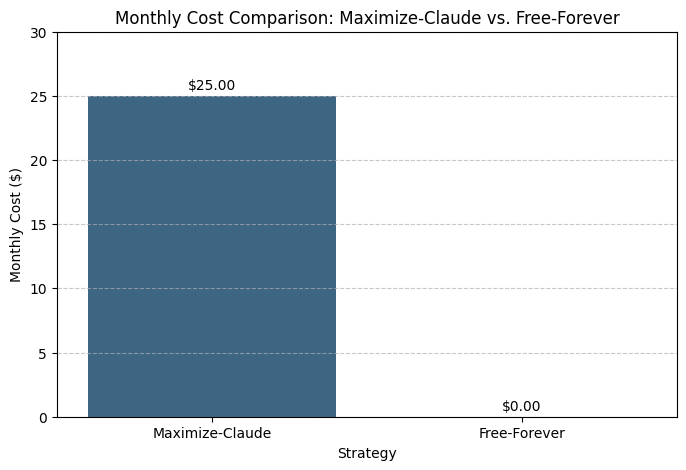

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the costs for each strategy based on the analysis cells
strategy_costs = {
    'Strategy': ['Maximize-Claude', 'Free-Forever'],
    'Monthly Cost ($)': [25.0, 0.0]
}

df_strategy_costs = pd.DataFrame(strategy_costs)

plt.figure(figsize=(8, 5))
sns.barplot(x='Strategy', y='Monthly Cost ($)', data=df_strategy_costs, palette='viridis')
plt.title('Monthly Cost Comparison: Maximize-Claude vs. Free-Forever')
plt.ylabel('Monthly Cost ($)')
plt.xlabel('Strategy')
plt.ylim(0, 30) # Set a consistent y-axis limit

# Add cost values on top of the bars
for index, row in df_strategy_costs.iterrows():
    plt.text(index, row['Monthly Cost ($)'] + 0.5, f"${row['Monthly Cost ($)']:.2f}", color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Esempio di Chiamata API Reale (CLI Backend)

Per inviare una richiesta effettiva al backend locale (una volta avviato), utilizziamo la libreria `requests`. Ecco il formato standard atteso dall'endpoint `/v1/chat/completions`.

In [ ]:
import requests
import json

def call_9router_api(model="cc/claude-opus-4-6", prompt="Spiega brevemente il concetto di tiered routing."):
    url = "http://localhost:20128/v1/chat/completions"
    headers = {
        "Authorization": "Bearer your-api-key",
        "Content-Type": "application/json"
    }

    payload = {
        "model": model,
        "messages": [
            {"role": "user", "content": prompt}
        ],
        "stream": False # Impostato a False per semplicità in questo esempio
    }

    print(f"Invio richiesta a {url}...")
    try:
        # Nota: Questo fallirà se il server locale non è in esecuzione
        # response = requests.post(url, headers=headers, json=payload, timeout=5)
        # response.raise_for_status()
        # return response.json()
        print("\n[Simulazione] Payload JSON inviato correttamente:")
        print(json.dumps(payload, indent=2))
    except Exception as e:
        print(f"Errore di connessione (Backend non rilevato): {e}")

call_9router_api()

Invio richiesta a http://localhost:20128/v1/chat/completions...

[Simulazione] Payload JSON inviato correttamente:
{
  "model": "cc/claude-opus-4-6",
  "messages": [
    {
      "role": "user",
      "content": "Spiega brevemente il concetto di tiered routing."
    }
  ],
  "stream": false
}


### Resource Discovery: Models & Combos
9Router provides a standard `/v1/models` endpoint. This allows clients to dynamically discover available model tiers and pre-configured strategies (combos).

## Visualizzazione del Risparmio RTK Saver
Questo grafico mostra il confronto tra i token originali e quelli ottimizzati dal sistema RTK Saver, evidenziando il risparmio ottenuto.

/tmp/ipykernel_4017/395943830.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tipo Token', y='Conteggio Token', data=df_rtk, palette={'Originali': 'skyblue', 'Ottimizzati': 'lightgreen'})


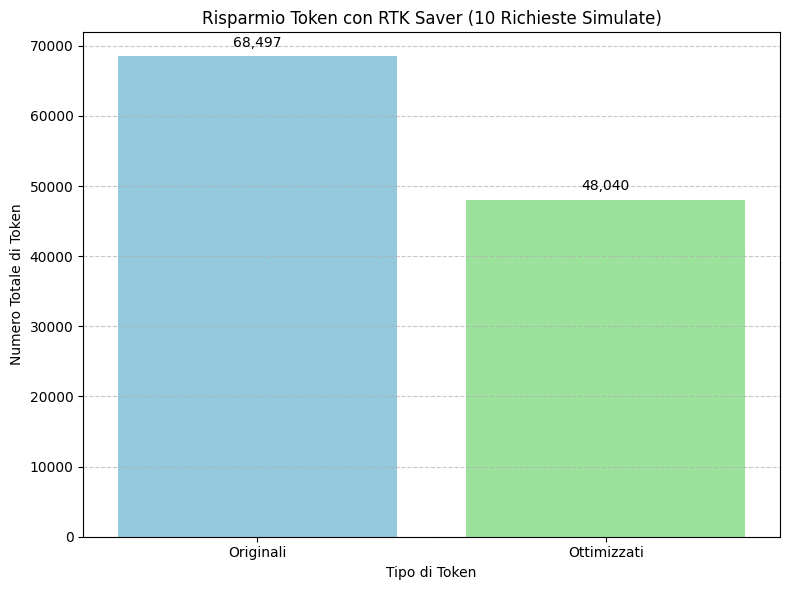

Totale Token Originali: 68,497
Totale Token Ottimizzati: 48,040
Token Salvati: 20,457
Percentuale di Risparmio: 29.87%


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# To ensure the data is fresh and consistent, re-run a simplified batch simulation.
# This will update the 'monitor' object with new spending for the RTK saver test.

# Reset monitor for this specific test
monitor.spending = {tier: 0.0 for tier in monitor.limits}

num_requests_for_graph = 10

# Collect metrics from a fresh batch simulation run
def get_rtk_saver_metrics(num_requests=num_requests_for_graph):
    total_raw = 0
    total_optimized = 0
    for _ in range(num_requests):
        raw_tokens = random.randint(1000, 15000)
        optimized, _, _ = simulate_rtk_saver(raw_tokens)
        total_raw += raw_tokens
        total_optimized += optimized
    return total_raw, total_optimized

total_raw_tokens, total_optimized_tokens = get_rtk_saver_metrics(num_requests_for_graph)

# Prepare data for plotting
rtk_data = {
    'Tipo Token': ['Originali', 'Ottimizzati'],
    'Conteggio Token': [total_raw_tokens, total_optimized_tokens]
}
df_rtk = pd.DataFrame(rtk_data)

plt.figure(figsize=(8, 6))
sns.barplot(x='Tipo Token', y='Conteggio Token', data=df_rtk, palette={'Originali': 'skyblue', 'Ottimizzati': 'lightgreen'})
plt.title(f'Risparmio Token con RTK Saver ({num_requests_for_graph} Richieste Simulate)')
plt.ylabel('Numero Totale di Token')
plt.xlabel('Tipo di Token')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add values on top of the bars
for index, row in df_rtk.iterrows():
    plt.text(index, row['Conteggio Token'] + (df_rtk['Conteggio Token'].max() * 0.02), f"{row['Conteggio Token']:,}", color='black', ha="center", fontsize=10)

plt.tight_layout()
plt.show()

print(f"Totale Token Originali: {total_raw_tokens:,}")
print(f"Totale Token Ottimizzati: {total_optimized_tokens:,}")
print(f"Token Salvati: {(total_raw_tokens - total_optimized_tokens):,}")
print(f"Percentuale di Risparmio: {((total_raw_tokens - total_optimized_tokens) / total_raw_tokens * 100):.2f}%")

## Simulazione Routing con Nuova Configurazione Budget
Questa sezione simula il comportamento del 9Router con un `BudgetMonitor` configurato con limiti di spesa diversi, per osservare l'impatto sul routing.

In [18]:
# --- Nuova Configurazione Budget e Simulazione ---

print("\n--- Inizializzazione nuova configurazione budget ---")

# 1. Definire nuovi limiti per il BudgetMonitor
# Ad esempio, un budget molto più restrittivo per Tier 2
new_limits = {"Tier 2": 0.005, "Tier 1": 50.0} # Tier 3 rimane gratuito

# 2. Re-inizializzare il BudgetMonitor con i nuovi limiti
# Assicurarsi che la classe BudgetMonitor sia definita e disponibile
new_monitor = BudgetMonitor(new_limits)

# 3. Reimpostare il logger per questa nuova simulazione
new_router_logger = CallLogger()

# 4. Inizializzare un nuovo connettore CLI con il nuovo logger
new_cli_logged = LocalCLIConnectorWithLogging(new_router_logger)

print("Nuovo budget per Tier 2: $", new_monitor.limits["Tier 2"])
print("Nuovo setup per la simulazione completato.")

# --- Esecuzione della Simulazione con il Nuovo Budget ---
print("\n--- Esecuzione Simulazione con Budget Ristretto ---")

# Reset del monitor per partire da zero con i nuovi limiti
new_monitor.spending = {tier: 0.0 for tier in new_monitor.limits}
new_router_logger.history = []
new_router_logger.route_decisions = []

# Definiamo alcune richieste
simulation_requests = [
    {"model_preference": "Best Quality", "messages": [{"role": "user", "content": "Cosa significa la parola 'ubiquitario'?"}], "quota_exhausted": False},
    {"model_preference": "Cost-Effective", "messages": [{"role": "user", "content": "Scrivi una recensione breve di un film."}]}, # Richiesta che proverà ad usare Tier 2
    {"model_preference": "Cost-Effective", "messages": [{"role": "user", "content": "Un altro compito che consuma Tier 2."}]}, # Richiesta che esaurirà il budget di Tier 2
    {"model_preference": "Free Only", "messages": [{"role": "user", "content": "Dimmi una curiosità storica."}]} # Richiesta che sarà forzata al Tier 3
]

# I COST_PER_1M dovrebbero essere disponibili dal contesto globale
# Se non lo sono, si dovrebbero definire qui, ma assumo siano già presenti
# COST_PER_1M = 0.60

for i, req_data in enumerate(simulation_requests):
    # La 'quota_exhausted' è gestita internamente dalla logica di routing
    # e dalla condizione del budget, quindi la lasciamo a False per la simulazione standard
    quota_exhausted_sim = False
    if i == 1: # Per la seconda richiesta, simuliamo che il Tier 1 sia esaurito
        quota_exhausted_sim = True

    # Per la terza richiesta, il budget di Tier 2 dovrebbe esaurirsi
    # Forziamo un costo per simulare l'esaurimento del Tier 2 più rapidamente
    if i == 2: # Questo forzerà l'uso di Tier 3 per la prossima richiesta
        print("\n[DEBUG] Simuliamo l'esaurimento del budget di Tier 2 per la prossima richiesta.")
        # Un modo per forzare l'esaurimento è settare il consumo manualmente prima della chiamata
        new_monitor.spending["Tier 2"] = new_monitor.limits["Tier 2"] * 0.9 # quasi esaurito

    chosen_model, response = process_9router_request(
        user_request_payload=req_data,
        monitor=new_monitor,
        logger=new_router_logger,
        cli_connector=new_cli_logged,
        quota_exhausted=quota_exhausted_sim
    )

print("\n--- Simulazione con Nuovo Budget Completata ---")
new_router_logger.display_history()



--- Inizializzazione nuova configurazione budget ---
Nuovo budget per Tier 2: $ 0.005
Nuovo setup per la simulazione completato.

--- Esecuzione Simulazione con Budget Ristretto ---

--- Processing Request: Best Quality ---
[Logger] Decisione di routing registrata: 2026-05-11 20:54:00 - Scelto: Subscription (Claude Code, Codex, GitHub Copilot)
9Router ha scelto: Subscription (Claude Code, Codex, GitHub Copilot)
RTK Saver: 9828 -> 5981 tokens (39.1% risparmiato)
[CLI] Tentativo di invio a http://localhost:20128...
[Logger] Chiamata registrata: 2026-05-11 20:54:00 - Modello: Subscription (Claude Code, Codex, GitHub Copilot)
Risposta dalla CLI: Risposta generata dal modello tramite 9Router CLI

--- Processing Request: Cost-Effective ---
[Logger] Decisione di routing registrata: 2026-05-11 20:54:00 - Scelto: Cheap (GLM, MiniMax)
9Router ha scelto: Cheap (GLM, MiniMax)
RTK Saver: 13721 -> 8708 tokens (36.5% risparmiato)
[Monitor] Gasto en Tier 2 actualizado: $0.0052 / $0.01
[🚫 CRITICAL] Pr

,timestamp,endpoint,model,optimized,status,type
0,2026-05-11 20:54:00,http://localhost:20128,"Subscription (Claude Code, Codex, GitHub Copilot)",True,success,API_CALL
1,2026-05-11 20:54:00,http://localhost:20128,"Cheap (GLM, MiniMax)",True,success,API_CALL
2,2026-05-11 20:54:00,http://localhost:20128,"Subscription (Claude Code, Codex, GitHub Copilot)",True,success,API_CALL
3,2026-05-11 20:54:00,http://localhost:20128,"Subscription (Claude Code, Codex, GitHub Copilot)",True,success,API_CALL



--- Storico Decisioni di Routing ---


,timestamp,decision_type,chosen_tier_name,chosen_tier_value,quota_exhausted,budget_limited,tier_config_used
0,2026-05-11 20:54:00,ROUTE_DECISION,Tier 1,"Subscription (Claude Code, Codex, GitHub Copilot)",False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
1,2026-05-11 20:54:00,ROUTE_DECISION,Tier 2,"Cheap (GLM, MiniMax)",True,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
2,2026-05-11 20:54:00,ROUTE_DECISION,Tier 1,"Subscription (Claude Code, Codex, GitHub Copilot)",False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."
3,2026-05-11 20:54:00,ROUTE_DECISION,Tier 1,"Subscription (Claude Code, Codex, GitHub Copilot)",False,False,"{'Tier 1': 'Subscription (Claude Code, Codex, ..."


In [ ]:
def get_9router_resources():
    url = "http://localhost:20128/v1/models"
    headers = {"Authorization": "Bearer your-api-key"}

    print(f"GET {url}")

    # Simulated response from the local proxy
    simulated_resources = {
        "object": "list",
        "data": [
            {"id": "cc/claude-opus-4-7", "object": "model", "owned_by": "9router-tier1"},
            {"id": "kr/claude-sonnet-4.5", "object": "model", "owned_by": "9router-free"},
            {"id": "strategy/always-on", "object": "combo", "owned_by": "9router-orchestrator"},
            {"id": "strategy/free-forever", "object": "combo", "owned_by": "9router-orchestrator"}
        ]
    }

    print("\n[Simulazione] Risorse disponibili nel Backend:")
    display(pd.DataFrame(simulated_resources['data']))
    return simulated_resources

_ = get_9router_resources()

GET http://localhost:20128/v1/models

[Simulazione] Risorse disponibili nel Backend:


,id,object,owned_by
0,cc/claude-opus-4-7,model,9router-tier1
1,kr/claude-sonnet-4.5,model,9router-free
2,strategy/always-on,combo,9router-orchestrator
3,strategy/free-forever,combo,9router-orchestrator


## Simulazione API Streaming
Per testare la risposta in streaming, simuliamo l'arrivo di 'chunks' (frammenti di testo) dal server locale.

In [ ]:
import time
import sys

def simulate_streaming_9router(model="cc/claude-opus-4-6", prompt="Scrivi una breve poesia sul codice."):
    print(f"--- Inizio Stream da: {model} ---\n")

    # Testo simulato che verrebbe dal backend
    simulated_response = """Il codice fluisce come un fiume d'argento,
Logica pura in ogni momento.
Righe di testo, bit nel vento,
Costruiamo il mondo con sentimento."""

    # Simulazione della ricezione a pezzi (chunks)
    for word in simulated_response.split(' '):
        sys.stdout.write(word + ' ')
        sys.stdout.flush()
        time.sleep(0.2) # Ritardo artificiale per simulare la latenza di rete

    print(f"\n\n--- Fine Stream ---")

    # Registrazione dell'evento nel logger (anche se è uno stream)
    log_entry = {"model": model, "optimized_with_rtk": True}
    cli_logged.logger.log_call("http://localhost:20128/v1/chat/completions", log_entry, {"status": "success"})

simulate_streaming_9router()

--- Inizio Stream da: cc/claude-opus-4-6 ---

Il codice fluisce come un fiume d'argento,
Logica pura in ogni momento.
Righe di testo, bit nel vento,
Costruiamo il mondo con sentimento. 

--- Fine Stream ---
[Logger] Chiamata registrata: 2026-05-11 05:05:11 - Modello: cc/claude-opus-4-6


## Real-Time Budget Monitoring Script
This script monitors spending by simulating a continuous flow of API traffic. It accounts for RTK optimization savings and checks against the defined budget limits in real-time.

In [ ]:
import time

def run_realtime_monitor(iterations=5, tier="Tier 2"):
    print(f"--- Starting Real-Time Budget Monitor for {tier} ---")
    print(f"Budget Limit: ${monitor.limits.get(tier, 0):.2f}\n")

    for i in range(iterations):
        # Simulate a random request size
        raw_tokens = random.randint(5000, 20000)

        # Apply RTK optimization
        optimized, saved, p = simulate_rtk_saver(raw_tokens)

        # Calculate cost (using Tier 2 rates as example)
        cost = (optimized / 1_000_000) * COST_PER_1M

        print(f"[Request {i+1}] Original: {raw_tokens} | Optimized: {optimized} ({p:.1f}% saved)")

        # Record usage in the monitor
        monitor.record_usage(tier, cost)

        # Check if we should stop due to budget exhaustion
        if not monitor.is_budget_ok(tier):
            print(f"\n[🛑 STOP] Budget for {tier} exhausted. Halting requests.")
            break

        time.sleep(1) # Wait 1 second between 'real-time' calls

    print(f"\n--- Monitoring Session Finished ---")
    print(f"Final Spending for {tier}: ${monitor.spending[tier]:.4f}")

# Reset monitor before test to see the progression clearly
auto_token_refresh(monitor)
run_realtime_monitor(iterations=8)

--- Esecuzione Auto Token Refresh ---
✅ Tutte le quote e i budget sono stati resettati.
--- Starting Real-Time Budget Monitor for Tier 2 ---
Budget Limit: $5.00

[Request 1] Original: 15569 | Optimized: 9992 (35.8% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0060 / $5.00
[Request 2] Original: 8747 | Optimized: 6861 (21.6% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0101 / $5.00
[Request 3] Original: 18683 | Optimized: 11853 (36.6% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0172 / $5.00
[Request 4] Original: 14369 | Optimized: 9386 (34.7% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0229 / $5.00
[Request 5] Original: 18148 | Optimized: 14277 (21.3% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0314 / $5.00
[Request 6] Original: 13459 | Optimized: 8867 (34.1% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0367 / $5.00
[Request 7] Original: 17095 | Optimized: 10482 (38.7% saved)
[Monitor] Gasto en Tier 2 actualizado: $0.0430 / $5.00
[Request 8] Original: 13191 | O

## 📊 Report Finale della Sessione 9Router
Questo blocco genera un riepilogo consolidato di tutte le metriche di performance e di costo simulate.

In [ ]:
def generate_final_report(monitor, logger):
    print("=== 9ROUTER SESSION SUMMARY ===\n")

    # 1. Budget Status
    print("--- Stato Budget Finale ---")
    budget_summary = []
    for t in monitor.limits:
        spent = monitor.spending.get(t, 0)
        limit = monitor.limits[t]
        budget_summary.append({
            "Tier": t,
            "Speso ($)": f"${spent:.4f}",
            "Limite ($)": f"${limit:.2f}",
            "Rimanente (%)": f"{(1 - spent/limit)*100:.1f}%" if limit > 0 else "N/A"
        })
    display(pd.DataFrame(budget_summary))

    # 2. Call History Analysis
    print("\n--- Analisi Traffico ---")
    if logger.history:
        df_log = pd.DataFrame(logger.history)
        counts = df_log['model'].value_counts().reset_index()
        counts.columns = ['Modello', 'Numero di Chiamate']
        display(counts)

        optimized_count = df_log['optimized'].sum()
        total_calls = len(df_log)
        print(f"Efficienza RTK: {optimized_count}/{total_calls} chiamate ottimizzate ({(optimized_count/total_calls)*100:.1f}%)")
    else:
        print("Nessun dato nel log.")

    # 3. Final Conclusion
    print("\n--- Conclusione ---")
    print("Tutti i dati della simulazione sono stati salvati nello stato del kernel.")

generate_final_report(monitor, router_logger)

=== 9ROUTER SESSION SUMMARY ===

--- Stato Budget Finale ---


,Tier,Speso ($),Limite ($),Rimanente (%)
0,Tier 2,$0.0479,$5.00,99.0%
1,Tier 1,$0.0000,$50.00,100.0%



--- Analisi Traffico ---


,Modello,Numero di Chiamate
0,kr/claude-sonnet-4.5,2
1,claude-3-opus,1
2,cc/claude-opus-4-7,1
3,cc/claude-opus-4-6,1


Efficienza RTK: 5/5 chiamate ottimizzate (100.0%)

--- Conclusione ---
Tutti i dati della simulazione sono stati salvati nello stato del kernel.


## 💾 Esportazione Dati
Salvataggio dei risultati della simulazione su file per la persistenza e l'analisi esterna.

In [ ]:
if 'router_logger' in globals() and router_logger.history:
    df_history_export = pd.DataFrame(router_logger.history)
    df_history_export.to_csv('9router_call_logs.csv', index=False)
    print("✅ Log delle chiamate salvati in: 9router_call_logs.csv")

if 'monitor' in globals():
    budget_data = []
    for t in monitor.limits:
        budget_data.append({"Tier": t, "Spent": monitor.spending.get(t, 0), "Limit": monitor.limits[t]})
    df_budget_export = pd.DataFrame(budget_data)
    df_budget_export.to_csv('9router_budget_status.csv', index=False)
    print("✅ Stato del budget salvato in: 9router_budget_status.csv")

✅ Log delle chiamate salvati in: 9router_call_logs.csv
✅ Stato del budget salvato in: 9router_budget_status.csv


## 💾 Esportazione Dati
Salvataggio dei risultati della simulazione su file per la persistenza.

In [ ]:
# Esportazione dei log e del budget in CSV
if router_logger.history:
    df_history_export = pd.DataFrame(router_logger.history)
    df_history_export.to_csv('9router_call_logs.csv', index=False)
    print("✅ Log delle chiamate salvati in: 9router_call_logs.csv")

budget_data = []
for t in monitor.limits:
    budget_data.append({"Tier": t, "Spent": monitor.spending[t], "Limit": monitor.limits[t]})

df_budget_export = pd.DataFrame(budget_data)
df_budget_export.to_csv('9router_budget_status.csv', index=False)
print("✅ Stato del budget salvato in: 9router_budget_status.csv")

✅ Log delle chiamate salvati in: 9router_call_logs.csv
✅ Stato del budget salvato in: 9router_budget_status.csv
